In [1]:
import zipfile

zip_path = "/content/chilli.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [2]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/dataset"))

['.config', 'chilli.zip', 'dataset', 'sample_data']
['Chilli Dataset']


In [3]:
import os

dataset_path = "/content/dataset/Chilli Dataset"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))

healthy : 2198
powdery mildew : 2031
cercospora : 2219
nutritional : 2032
mites_and_trips : 2507


In [4]:
import tensorflow as tf

dataset_path = "/content/dataset/Chilli Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 10987 files belonging to 5 classes.
Using 8790 files for training.
Found 10987 files belonging to 5 classes.
Using 2197 files for validation.


In [5]:
class_names = train_dataset.class_names

print(class_names)

['cercospora', 'healthy', 'mites_and_trips', 'nutritional', 'powdery mildew']


In [6]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [8]:
print(class_names)

['cercospora', 'healthy', 'mites_and_trips', 'nutritional', 'powdery mildew']


In [9]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [10]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
base_model.trainable = False

In [12]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(5, activation="softmax")(x)


googlenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [13]:
googlenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,854,437 (87.18 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [14]:
from tensorflow.keras.optimizers import Adam

googlenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_googlenet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

In [16]:
googlenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,854,437 (87.18 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [17]:
history_googlenet = googlenet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6216 - loss: 1.0863
Epoch 1: val_accuracy improved from None to 0.82886, saving model to best_googlenet.keras

Epoch 1: finished saving model to best_googlenet.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - accuracy: 0.7148 - loss: 0.7827 - val_accuracy: 0.8289 - val_loss: 0.4771 - learning_rate: 0.0010
Epoch 2/20
274/275 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7946 - loss: 0.5539
Epoch 2: val_accuracy improved from 0.82886 to 0.85981, saving model to best_googlenet.keras

Epoch 2: finished saving model to best_googlenet.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - accuracy: 0.8010 - loss: 0.5295 - val_accuracy: 0.8598 - val_loss: 0.3930 - learning_rate: 0.0010
Epoch 3/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8277 - loss: 0.4714
Epoch 3: val_accuracy improved from 0.85981 to 0.86299, saving model to best_googlenet.keras

Epoch 3: finished saving model to best_googlenet.keras
275/275

In [18]:
import os

print(os.path.exists("best_googlenet.keras"))

True


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import shutil

shutil.copy(
    "best_googlenet.keras",
    "/content/drive/MyDrive/best_googlenet.keras"
)

print("Model saved to Google Drive successfully.")

Model saved to Google Drive successfully.


In [21]:
from google.colab import files

files.download("best_googlenet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import tensorflow as tf

best_model = tf.keras.models.load_model("best_googlenet.keras")

In [23]:
loss, accuracy = best_model.evaluate(validation_dataset)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9445 - loss: 0.1750
Validation Loss : 0.1749572902917862
Validation Accuracy : 0.9444697499275208


In [24]:
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision :", precision_score(y_true, y_pred, average="weighted"))
print("Recall :", recall_score(y_true, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_true, y_pred, average="weighted"))

Accuracy : 0.94446973145198
Precision : 0.9451085611530836
Recall : 0.94446973145198
F1 Score : 0.9445481087166786


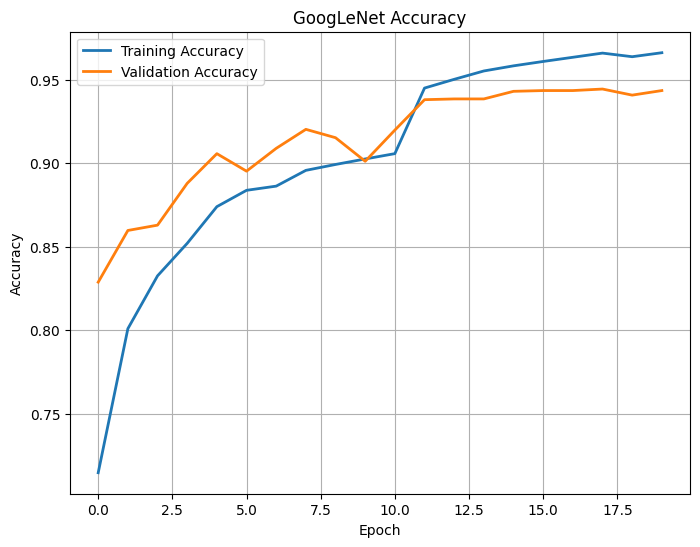

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_googlenet.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_googlenet.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title("GoogLeNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("googlenet_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

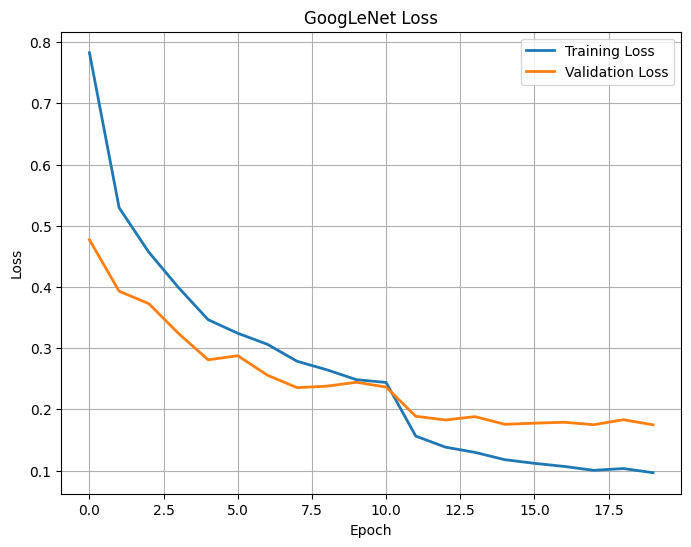

In [27]:
plt.figure(figsize=(8,6))

plt.plot(history_googlenet.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_googlenet.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title("GoogLeNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("googlenet_loss.png", dpi=300, bbox_inches='tight')

plt.show()

In [28]:
import os

print(os.path.exists("googlenet_accuracy.png"))
print(os.path.exists("googlenet_loss.png"))

True
True


In [29]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

shutil.copy("googlenet_accuracy.png",
            "/content/drive/MyDrive/googlenet_accuracy.png")

shutil.copy("googlenet_loss.png",
            "/content/drive/MyDrive/googlenet_loss.png")

print("Graphs saved to Google Drive successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Graphs saved to Google Drive successfully.


In [30]:
from google.colab import files

files.download("googlenet_accuracy.png")
files.download("googlenet_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>